# Exploratory Data Analysis (EDA) of Heart Disease Dataset

In this notebook, I am analyzing a popular Heart Disease dataset to uncover patterns and relationships between various clinical features and the likelihood of a heart disease diagnosis. 

This project demonstrates how to manipulate data using `pandas` and create visualizations using `matplotlib` directly within a Jupyter environment. 

**Our main objectives in this notebook are:**
1. To load and inspect the clinical data.
2. To analyze the relationship between a patient's age and their diagnosis rate by grouping them into age brackets.
3. To generate a correlation heatmap that identifies which clinical test results most strongly predict heart disease.
4. Continuous Variables Distribution & Outliers (Boxplots)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('heart.csv')

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


### Age vs. Diagnosis
In this section, I want to see how age impacts the likelihood of heart disease. Instead of looking at individual ages, we will group the patients into 10-year "bins" (e.g., 30-40, 41-50) using `pd.cut()`.

In [4]:
# sorting patients' age into bins

bins = [20, 30, 40, 50, 60, 70, 80]
labels = ['20-30', '31-40', '41-50', '51-60', '61-70', '71-80']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

In [6]:
# total patients and sick patients per age group
age_stats = df.groupby('age_group', observed=False)['target'].agg(['count', 'sum']).reset_index()

print(age_stats)

  age_group  count  sum
0     20-30      4    4
1     31-40     64   41
2     41-50    247  166
3     51-60    438  204
4     61-70    252   94
5     71-80     20   17


In [7]:
# percentage of sick patients
age_stats['percent_sick'] = (age_stats['sum'] / age_stats['count']) * 100

print(age_stats)

  age_group  count  sum  percent_sick
0     20-30      4    4    100.000000
1     31-40     64   41     64.062500
2     41-50    247  166     67.206478
3     51-60    438  204     46.575342
4     61-70    252   94     37.301587
5     71-80     20   17     85.000000


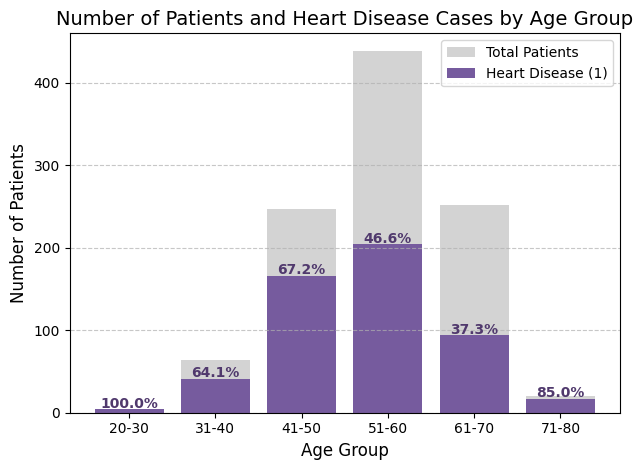

In [15]:
# plot
plt.bar(age_stats['age_group'], age_stats['count'], color='lightgray', label='Total Patients')
plt.bar(age_stats['age_group'], age_stats['sum'], color='#765b9e', label='Heart Disease (1)')

plt.title('Number of Patients and Heart Disease Cases by Age Group', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# adding percentage
for i in range(len(age_stats)):
    percent = age_stats['percent_sick'].iloc[i]
    if pd.notna(percent): 
        plt.text(i, age_stats['sum'].iloc[i] + 2, f'{percent:.1f}%', ha='center', color='#50396d', fontweight='bold')

plt.tight_layout()
plt.show()

Looking at the generated bar chart, we can observe a pattern. The highest volume of patients in this dataset falls into the **51-60 age group**, but their diagnosis rate is 46.6%. However, the **41-50 age group** shows a strikingly high positive diagnosis rate of **67.2%**. We can also see that while the sample size for the oldest group (71-80) is very small, almost all of them (85.0%) have a positive diagnosis.

The youngest group (**20-30 years old**) shows a 100.0% diagnosis rate. However, there are only 4 patients in this bracket. Because this sample size is so small, this is a statistical outlier rather than a general medical rule. These young patients were likely included in the dataset precisely because they already had severe, unusual symptoms that required extensive testing.

### Correlation Matrix
I will calculate the Pearson correlation coefficient between all numerical features. This tells us which medical indicators move together and, most importantly, which ones are strongly tied to the `target` (the diagnosis).

In [16]:
# drop age group
df_numeric = df.drop(columns=['age_group'])

In [17]:
corr_matrix = df_numeric.corr()

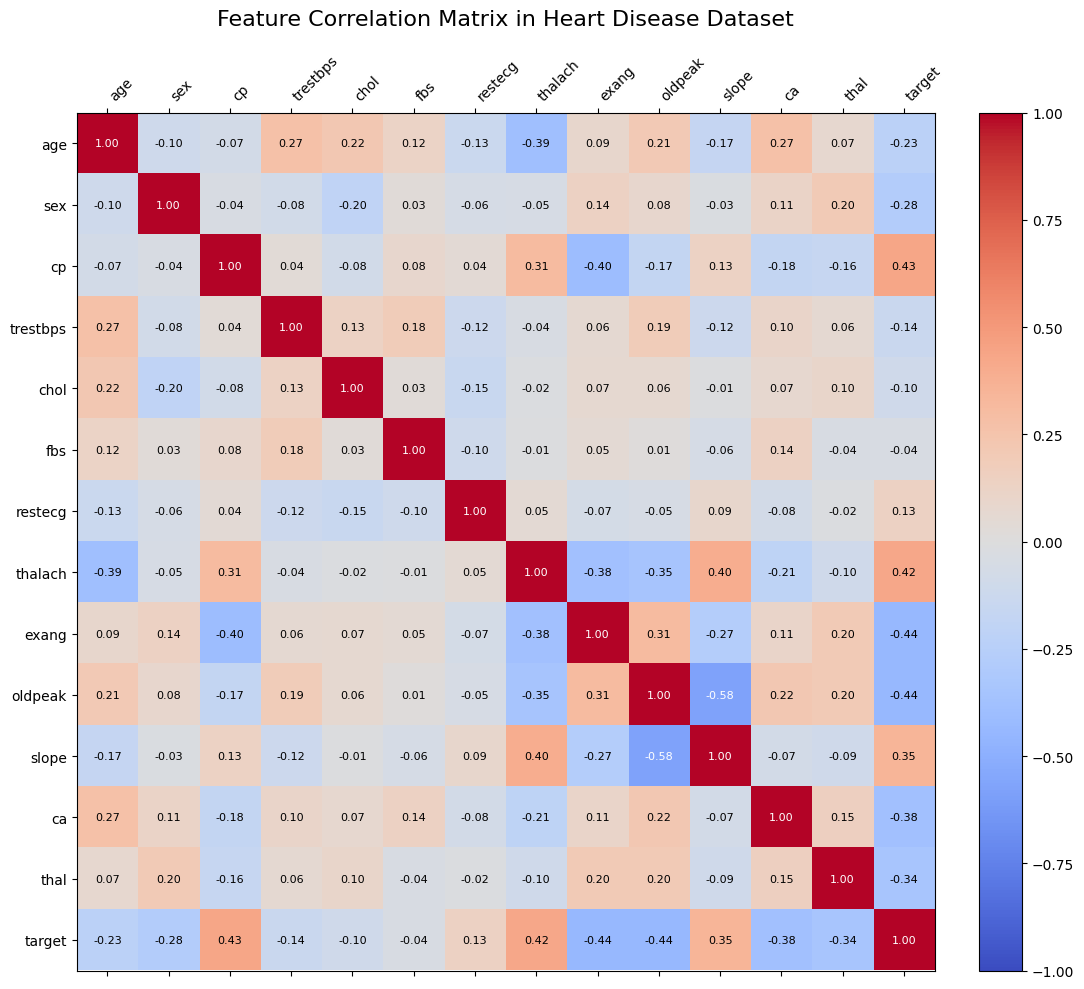

In [18]:
# visualisation
fig, ax = plt.subplots(figsize=(12, 10))

# red is positive, blue is negative
cax = ax.matshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

fig.colorbar(cax, fraction=0.046, pad=0.04)

columns = corr_matrix.columns
ax.set_xticks(np.arange(len(columns)))
ax.set_yticks(np.arange(len(columns)))
ax.set_xticklabels(columns, rotation=45, ha='left', fontsize=10)
ax.set_yticklabels(columns, fontsize=10)

# add correlation values inside each cell
for i in range(len(columns)):
    for j in range(len(columns)):
        value = corr_matrix.iloc[i, j]
        text_color = "white" if abs(value) > 0.5 else "black"
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", color=text_color, fontsize=8)

plt.title('Feature Correlation Matrix in Heart Disease Dataset', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

When reading correlation metrics, the **absolute value** (distance from zero) determines the strength of the relationship. This means a deep blue (-0.44) is a mathematically stronger predictor than a deep red (0.43).

* **The Strongest Overall Predictors (Negative):** Exercise-induced angina (`exang`, **-0.44**) and ST depression (`oldpeak`, **-0.44**) show the strongest correlation with the target. A negative value indicates an inverse relationship. In the context of this dataset, it means that the *absence* of exercise-induced angina or *lower* values of ST depression are actually the strongest indicators of a positive diagnosis (`target=1`).
* **The Strongest Positive Predictors:** Chest pain type (`cp`, **0.43**) and maximum heart rate achieved (`thalach`, **0.42**). The relationship is direct: specific types of chest pain and higher maximum heart rates increase the likelihood of heart disease.

### Continuous Variables Distribution & Outliers (Boxplots)
Now I will examine the distribution of three key continuous clinical variables: Resting Blood Pressure (`trestbps`), Cholesterol (`chol`), and Maximum Heart Rate Achieved (`thalach`).

I will split the data by our `target` variable to visually compare healthy patients (0) against those diagnosed with heart disease (1).

C:\Users\PC\AppData\Local\Temp\ipykernel_2184\1085051462.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot([healthy_data, disease_data],
C:\Users\PC\AppData\Local\Temp\ipykernel_2184\1085051462.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot([healthy_data, disease_data],
C:\Users\PC\AppData\Local\Temp\ipykernel_2184\1085051462.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot([healthy_data, disease_data],


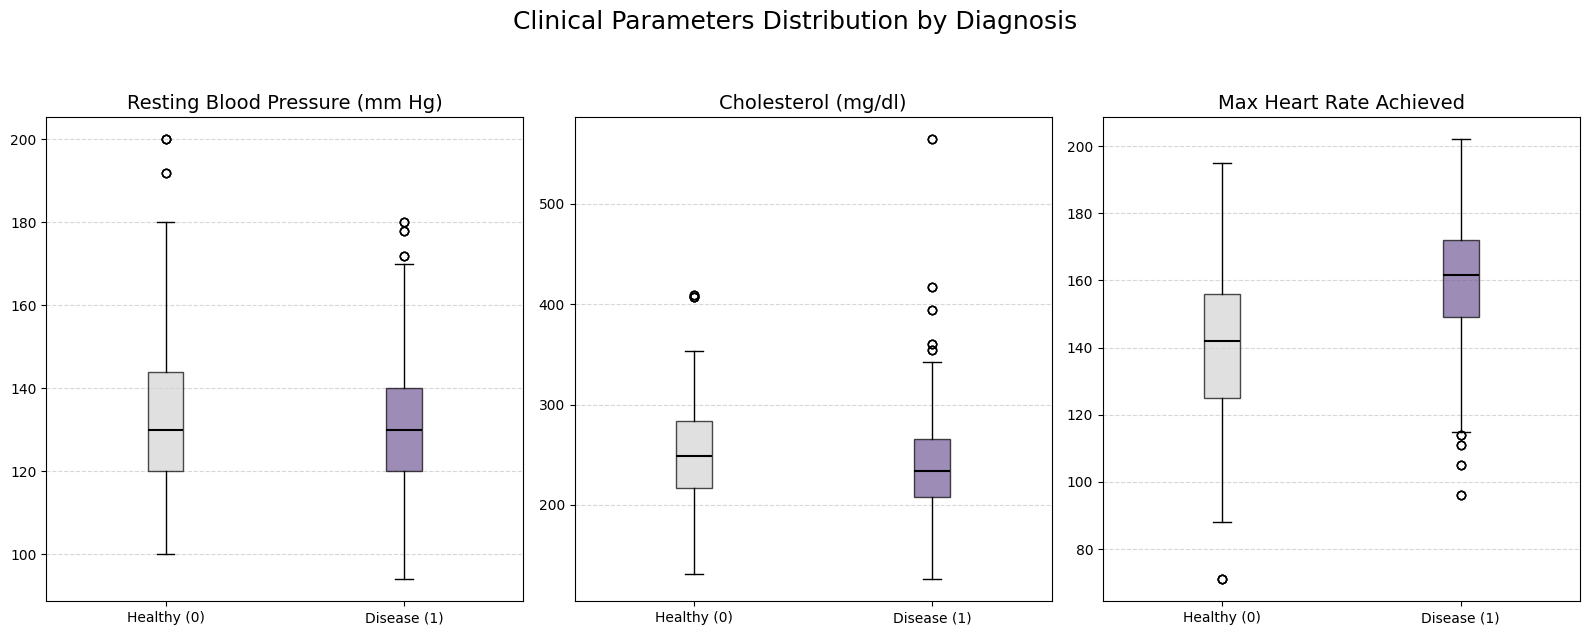

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

features = ['trestbps', 'chol', 'thalach']
titles = ['Resting Blood Pressure (mm Hg)', 'Cholesterol (mg/dl)', 'Max Heart Rate Achieved']

for i, feature in enumerate(features):
    healthy_data = df[df['target'] == 0][feature]
    disease_data = df[df['target'] == 1][feature]

    box = axes[i].boxplot([healthy_data, disease_data], 
                          labels=['Healthy (0)', 'Disease (1)'],
                          patch_artist=True,
                          medianprops={'color': 'black', 'linewidth': 1.5})

    colors = ['lightgray', '#745b97']
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    axes[i].set_title(titles[i], fontsize=14)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Clinical Parameters Distribution by Diagnosis', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

In [23]:
features = ['trestbps', 'chol', 'thalach']
medians_df = df.groupby('target')[features].median()

medians_df.index = ['Healthy (0)', 'Disease (1)']

medians_df.columns = ['Resting Blood Pressure', 'Cholesterol', 'Max Heart Rate']

display(medians_df)

,Resting Blood Pressure,Cholesterol,Max Heart Rate
Healthy (0),130.0,249.0,142.0
Disease (1),130.0,234.0,161.5


Based on the generated visualizations, we can observe the actual spread of the continuous clinical data and how it relates to the diagnosis:

* **Resting Blood Pressure (`trestbps`):** The distributions for both groups are nearly identical, with the medians sitting right around 130 mm Hg for both healthy and diagnosed patients. This visually confirms that resting blood pressure alone is not a strong differentiator in this specific dataset.
* **Cholesterol (`chol`):** Surprisingly, the median cholesterol level is slightly *lower* for the disease group compared to the healthy group. Both groups share a similar interquartile range (the box size) and feature significant outliers—including one extreme case in the disease group nearing 600 mg/dl. Because the distributions overlap so heavily, cholesterol is a weak standalone predictor here.
* **Max Heart Rate Achieved (`thalach`):** This is the only feature among the three that shows a clear separation. The entire "box" (representing the middle 50% of the patients) and the median are noticeably higher for the disease group (median ~160) compared to the healthy group (median ~140). This perfectly aligns with our correlation matrix: higher maximum heart rates achieved during the test are strongly associated with a positive diagnosis.